In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [51]:
df=pd.read_csv("E:\CSV files\Social_Network_Ads.csv")
df

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [53]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,400.0,37.6550,10.482877,18.0,29.75,37.0,46.0,60.0
EstimatedSalary,400.0,69742.5000,34096.960282,15000.0,43000.00,70000.0,88000.0,150000.0
Purchased,400.0,0.3575,0.479864,0.0,0.00,0.0,1.0,1.0


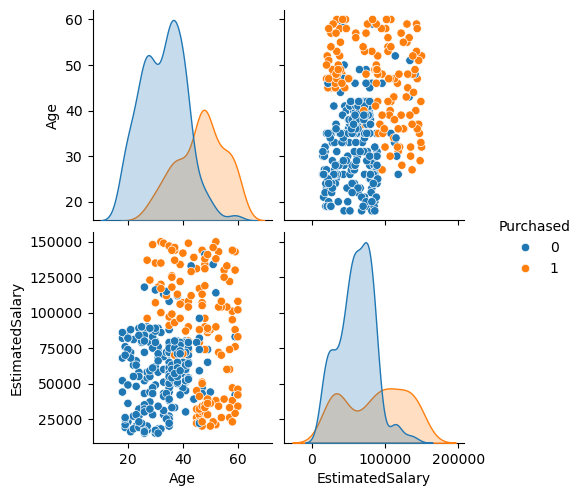

In [54]:
sns.pairplot(data=df,hue="Purchased")
plt.show()

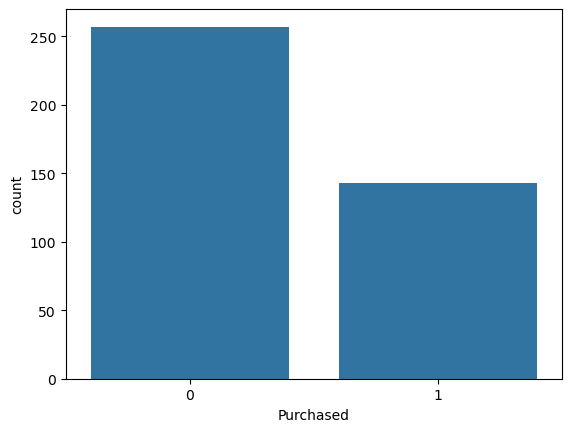

In [55]:
sns.countplot(data=df,x="Purchased")
plt.show()

In [56]:
df.value_counts("Purchased")

Purchased
0    257
1    143
Name: count, dtype: int64

In [57]:
X=df.drop("Purchased",axis=1)
y=df["Purchased"]

In [58]:
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [59]:
y

0      0
1      0
2      0
3      0
4      0
      ..
395    1
396    1
397    1
398    0
399    1
Name: Purchased, Length: 400, dtype: int64

In [60]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=26
)

In [61]:
X_train

,Age,EstimatedSalary
320,52,138000
323,48,30000
188,35,72000
135,23,63000
185,31,66000
...,...,...
211,52,150000
102,32,86000
262,55,125000
318,45,32000


In [62]:
X_test

,Age,EstimatedSalary
36,33,28000
30,31,74000
301,48,74000
325,41,60000
345,41,63000
...,...,...
213,35,58000
74,32,18000
71,24,27000
246,35,50000


In [63]:
y_train.shape

(320,)

In [64]:
y_test.shape

(80,)

In [65]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [66]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import  accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
k_values=range(3,10,2)
for k in k_values:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train,y_train)
    y_pred=model.predict(X_test)
    
    # metrics
    
    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    cm=confusion_matrix(y_test,y_pred)
    
    print(f'Accuracy Score for kth value of {k} : {accuracy}')
    print(f'Precision Score for kth value of {k} : {precision}')
    print(f'Recall Score for kth value of {k} : {recall}')
    print(f'F1 score for kth value of {k} : {f1}')
    print(f'Confusion Matrix for kth value of {k} : {cm}')
    print()

Accuracy Score for kth value of 3 : 0.8875
Precision Score for kth value of 3 : 0.7037037037037037
Recall Score for kth value of 3 : 0.95
F1 score for kth value of 3 : 0.8085106382978723
Confusion Matrix for kth value of 3 : [[52  8]
 [ 1 19]]

Accuracy Score for kth value of 5 : 0.9
Precision Score for kth value of 5 : 0.7307692307692307
Recall Score for kth value of 5 : 0.95
F1 score for kth value of 5 : 0.8260869565217391
Confusion Matrix for kth value of 5 : [[53  7]
 [ 1 19]]

Accuracy Score for kth value of 7 : 0.9
Precision Score for kth value of 7 : 0.7307692307692307
Recall Score for kth value of 7 : 0.95
F1 score for kth value of 7 : 0.8260869565217391
Confusion Matrix for kth value of 7 : [[53  7]
 [ 1 19]]

Accuracy Score for kth value of 9 : 0.9
Precision Score for kth value of 9 : 0.7307692307692307
Recall Score for kth value of 9 : 0.95
F1 score for kth value of 9 : 0.8260869565217391
Confusion Matrix for kth value of 9 : [[53  7]
 [ 1 19]]



### Optimal K Value Selection

After evaluating multiple K values (3, 5, 7, and 9), it was observed that K = 5, 7, and 9 provided similar performance across all evaluation metrics.

Among these, K = 5 is chosen as the optimal value because:
- It is the smallest among the best-performing values
- It helps capture local patterns more effectively
- It avoids unnecessary smoothing of the data

Thus, K = 5 provides a good balance between bias and variance.

In [67]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix
model=KNeighborsClassifier(n_neighbors=5)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
    
accuracy=accuracy_score(y_test,y_pred)
precision=precision_score(y_test,y_pred)
recall=recall_score(y_test,y_pred)
f1=f1_score(y_test,y_pred)
cm=confusion_matrix(y_test,y_pred)
    
print(f'Accuracy Score for kth value of 5 : {accuracy}')
print(f'Precision Score for kth value of 5 : {precision}')
print(f'Recall Score for kth value of 5 : {recall}')
print(f'F1 score for kth value of 5 : {f1}')
print(f'Confusion Matrix for kth value of 5 : {cm}')

Accuracy Score for kth value of 5 : 0.9
Precision Score for kth value of 5 : 0.7307692307692307
Recall Score for kth value of 5 : 0.95
F1 score for kth value of 5 : 0.8260869565217391
Confusion Matrix for kth value of 5 : [[53  7]
 [ 1 19]]


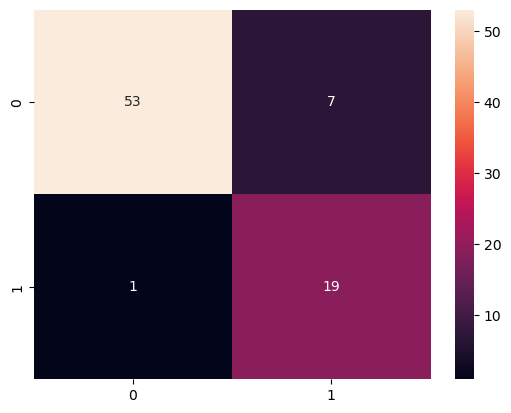

In [68]:
sns.heatmap(cm,annot=True)
plt.show()

In [69]:
df.loc[26]

Age                   49
EstimatedSalary    28000
Purchased              1
Name: 26, dtype: int64

In [70]:
df.loc[26].values

array([   49, 28000,     1])

In [71]:
new_test_data=[[49, 28000]]
new_test_data=scaler.transform(new_test_data)
model.predict(new_test_data)

array([1])

In [72]:
new_test_data=[[27, 68000]]
new_test_data=scaler.transform(new_test_data)
model.predict(new_test_data)

array([0])

In [73]:
pip install joblib

Note: you may need to restart the kernel to use updated packages.


In [74]:
import joblib
joblib.dump(model,"model.pkl")
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']